In [48]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# ※ Quiz : 경주여행과 전주여행에 대해 최빈단어 시각화와 유사도 분석
- (1) naver open API를 활용하여 네이버지식인 '전주여행', '경주여행'을 각각 500건씩 검색 백업
    * replace(), re.sum() 이용
    * 백업 파일 결과 : query, no, title, link, description, total_text(title + ' ' + description)
- (2) 품사태깅 백업(naver_pos.csv)
    * query, no, token, pos
- (3) 명사만 추출 백업(naver_pos_nouns.csv) 
    * query, token, pos
- (4) 빈도분석(naver_pos_nouns_count.csv)
    * token, 경주빈도, 전주빈도, 빈도합
- (5) 빈도 시각화(워드클라우드, Text.plot)
    * 워드 클라우드 이미지 저장
- (6) 단어간 유사도 분석(Word2Vec, 연관분석)

# 1. naver open API를 활용하여 검색어 500건씩 추출
- query, no, title, link, description, total_text(title + ' ' + description)

In [1]:
%ls

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: A014-DCD6

 C:\ai\source\07_자연어처리 디렉터리

2025-12-02  오후 02:56    <DIR>          .
2025-12-02  오후 02:56    <DIR>          ..
2025-12-02  오후 02:56                58 .env
2025-12-02  오후 12:57    <DIR>          .ipynb_checkpoints
2025-12-02  오후 02:56             8,228 ch01_to_03_한글형태소분석_시각화_유사도분석_Quiz.ipynb
2025-12-01  오후 05:58           313,200 ch02_코랩에서_실행한_헌법data빈도시각화(wordcloud, 그래프).ipynb
2025-12-02  오후 12:44         2,033,977 ch02_한글형태소분석_시각화.ipynb
2025-12-02  오후 01:01            28,538 ch03_연관분석.ipynb
2025-12-01  오전 11:50            93,989 ch1_NLTK자연어처리.ipynb
2025-12-01  오후 05:18    <DIR>          data
               6개 파일           2,477,990 바이트
               4개 디렉터리  119,391,563,776 바이트 남음


In [1]:
# .env 파일 가져오기(방법1)
from dotenv import load_dotenv
import os
load_dotenv(
#     dotenv_path='.env'
)
client_id = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")
print(client_id, client_secret)

4EFJuXTcTnIYo8yP7n4M bY6tRVKQYF


In [6]:
# .env 파일 가져오기(방법2)
from decouple import config

In [8]:
import requests
import pandas as pd
import json # repo
import re # 정규표현식
from html import unescape # discription에 &lt; &nbps; 등의 특수 문자를 <(문자)로 변경
client_id = os.getenv("CLIENT_ID")
client_secret = os.getenv("CLIENT_SECRET")

query = "경주 여행"
start = 1
headers = {
    'X-Naver-Client-Id':client_id,
    'X-Naver-Client-Secret':client_secret
}
# url = f"https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start}"
url="https://openapi.naver.com/v1/search/kin"
params={'query':query,'display':100, 'start': start}
response = requests.get(url,params=params, headers=headers)
# print(response.text[:500])

# items = json.loads(response.text)['items']
items = response.json()['items']
len(items)

100

In [20]:
# title, link, description 추출(b태그 삭제, 특수문자조정(&ㅎㅅ; -> >), 정규표현식을 이용한 한글추출)
item = items[97]
title = item.get('title').replace('<b>',"").replace('</b>',"")
link = item['link']
description = item.get('description').replace('<b>',"").replace('</b>',"")
# html 특수문자 처리
description = unescape(description)
# 정규표현식 : 알파벳, 숫자, 한글만 남기고 나머지는 제거
description = re.sub(r'[^a-zA-Z0-9가-힣]', ' ', description)
description = re.sub('\s+', ' ', description)
print(title, link, description)

경주 여행지 추천 https://kin.naver.com/qna/detail.naver?d1id=9&dirId=90111&docId=261370795&qb=6rK97KO8IOyXrO2WiQ==&enc=utf8  2 부산을 벗어난 경주 여행지 알려주세요 3 당일치기로 경주 여행코스 밑에 자세하게 권역별로 여행코스를 소개했습니다 경주여행이 처음이라면 대릉원 첨성대 참고로 쭈니아빠 블로그를 방문하시면 경주여행 


In [29]:
def get_search_element_return(query, start):
    headers = {
    'X-Naver-Client-Id':client_id,
    'X-Naver-Client-Secret':client_secret
    }
    # url = f"https://openapi.naver.com/v1/search/kin.json?query={query}&display=100&start={start}"
    url="https://openapi.naver.com/v1/search/kin"
    params={'query':query,'display':100, 'start': start}
    response = requests.get(url,params=params, headers=headers)
    # print(response.text[:500])

    # items = json.loads(response.text)['items']
    items = response.json()['items']
    result = [] # 검색한 정보를 append할 리스트
    for i, item in enumerate(items):
        title = item.get('title').replace('<b>','').replace('</b>','')
        link = item.get('link')
        description = item.get('description').replace('<b>','').replace('</b>','')
        # 특수문자 처리
        description= unescape(description)
        # 영문자, 숫자, 한글을 제외한 문자 제거
        description = re.sub(r'[^a-zA-Z0-9가-힣]',' ',description)
        description = re.sub('\s+', ' ', description)
        result.append({
            'query' : query,
            'no' : (start-1)*100 + i + 1,
            'title' : title,
            'link' : link,
            'description' : description,
            'total_text' : title + " " + description
        })
    return result

In [36]:
import time
result_total = [] # 모든 검색 결과
queries = ['전주 여행', '경주 여행']
maxstart = 5
for query in queries:
    for start in range(1, maxstart + 1):
        print(start, query, '읽는 중')
        result_total.extend(get_search_element_return(query, start))
        time.sleep(0.5)
df = pd.DataFrame(result_total)
df.to_csv('data/naver.csv', index= False, encoding='cp949')

1 전주 여행 읽는 중
2 전주 여행 읽는 중
3 전주 여행 읽는 중
4 전주 여행 읽는 중
5 전주 여행 읽는 중
1 경주 여행 읽는 중
2 경주 여행 읽는 중
3 경주 여행 읽는 중
4 경주 여행 읽는 중
5 경주 여행 읽는 중


# 2. 품사태깅 백업
- query, no, token, pos

In [38]:
import pandas as pd
pd.read_csv('data/naver.csv', encoding='cp949')
df.tail(2)

,query,no,title,link,description,total_text
998,경주 여행,499,경주 여행가면 볼거 많겠죠??,https://kin.naver.com/qna/detail.naver?d1id=9&...,중학생인데 경주 여행가볼려고 하는데 볼거 많겠죠 경주 가볼만한곳 입니다 불국사 첨성...,경주 여행가면 볼거 많겠죠?? 중학생인데 경주 여행가볼려고 하는데 볼거 많겠죠 경주...
999,경주 여행,500,경주여행!!,https://kin.naver.com/qna/detail.naver?d1id=9&...,경주 여행을 가려고 하는데 혹시 경주에 폴라로이드 카메라 대여 할 수 있는곳이나 싸...,경주여행!! 경주 여행을 가려고 하는데 혹시 경주에 폴라로이드 카메라 대여 할 수 ...


In [42]:
df_list = df[['query', 'no', 'total_text']].values.tolist()
df_list[::250]

[['전주 여행',
  1,
  '25년10월5,6,7일 전주여행  전주여행 가볼만한 곳 추천부탁드립니다 25년 10월 초 전주여행 아이들과 함께 가기 좋은 시점이에요 추석에는 문 연 곳이 적을 수 있지만 전주 한옥마을이나 전주비빔밥 맛집은 추천해용 차는 밀릴 가능성이 높으니 미리 출발하는 '],
 ['전주 여행',
  251,
  '[추천해주세요] 전주 당일치기 여행  추천해주세요 전주 당일치기 여행 전주여행 전주맛집 국내여행 전주달봉이 달봉티비 전주여행코스 전주가볼만한곳 여수여행 여수가볼만한곳 제주도여행 제주도가볼만한곳 여행 전문 인플루언서 전주달봉이입니다 '],
 ['경주 여행',
  1,
  'APEC 기간 경주여행 APEC 기간 경주여행 어떻게 생각하시나요 APEC 기간에 경주여행은 좋은 방법이에요 역사와 문화가 가득한 도시에서 특별한 경험을 할 수 있을 거에요 즐거운 여행 되세요 '],
 ['경주 여행',
  251,
  '경주 여행 코스 어디가★ 가족들이랑 경주여행을 가려고 하는데 경주 여행 코스를 어떻게 해야할지 모르겟네요 경주 여행 코스 어디가 좋을까요 사실 중학교때 가보고 안가봤어요 경주 여행코스 가장 핫플레이스만 가보고 싶어요 혹시 경주 여행코스 다들 ']]

In [47]:
from mecab import MeCab
analyzer = MeCab()
stopwords = {'전주', '경주', '여행'}
select_pos = ['NNG', 'NNP'] # Mecab의 명사 pos tag
postagged_list = [] # query, no, token, pos 딕셔너리 list

for i,row in enumerate(df_list): 
    query = row[0]
    no    = row[1]
    text  = row[2]
    tagged_text = analyzer.pos(text)
#     if i%250 == 0 :
#         print('{}의 {}번째 태깅 결과 :{}개'.format(query, no, len(tagged_text)))
#         print(tagged_text[:5])
    for token, pos in tagged_text:
        #if token not in stopwords and pos in select_pos: # 불용어 제외한 명사
        if token not in stopwords: # 불용어만 제외
            postagged_list.append({
                'query': query,
                'no' : no,
                'token' : token,
                'pos' : pos
            })
df_postagged = pd.DataFrame(postagged_list)
df_postagged.to_csv('data/naver_pos.csv', index=False, encoding='cp949')

# 3. 명사만 추출

In [50]:
import pandas as pd
df_postagged = pd.read_csv('data/naver_pos.csv', encoding='cp949')
df_postagged.head()

,query,no,token,pos
0,전주 여행,1,25,SN
1,전주 여행,1,년,NNBC
2,전주 여행,1,10,SN
3,전주 여행,1,월,NNBC
4,전주 여행,1,5,SN


In [53]:
select_pos = ['NNG', 'NNP']
df_nouns = df_postagged[df_postagged['pos'].isin(select_pos)]
df_nouns.to_csv('data/naver_pos_nouns.csv', index=False, encoding='cp949')

# 4. 빈도분석
- token 경주빈도, 전주빈도 빈도합

In [55]:
df_nouns = pd.read_csv('data/naver_pos_nouns.csv', encoding = 'cp949')
df_nouns.head()

,query,no,token,pos
0,전주 여행,1,곳,NNG
1,전주 여행,1,추천,NNG
2,전주 여행,1,부탁,NNG
3,전주 여행,1,아이,NNG
4,전주 여행,1,시점,NNG


In [57]:
df_nouns.groupby(['query','token'],as_index=False)['pos'].count()

,query,token,pos
0,경주 여행,가격,5
1,경주 여행,가능,30
2,경주 여행,가보세요,10
3,경주 여행,가본적,5
4,경주 여행,가시,5
...,...,...,...
997,전주 여행,효율,5
998,전주 여행,후,5
999,전주 여행,휴가,5
1000,전주 여행,휴무,5


In [60]:
df_token_grp = df_nouns.groupby('query')['token'].value_counts()
df_token_grp = df_token_grp.reset_index(name='token_count')

In [62]:
df_token_grp.head()

,query,token,token_count
0,경주 여행,코스,447
1,경주 여행,추천,424
2,경주 여행,계획,151
3,경주 여행,곳,134
4,경주 여행,맛집,133


In [67]:
df_gj = df_token_grp.loc[df_token_grp['query'] == '경주 여행', ['token', 'token_count']]
df_jj = df_token_grp.loc[df_token_grp['query'] == '전주 여행', ['token', 'token_count']]
df_gj.shape, df_jj.shape

((536, 2), (466, 2))

In [70]:
df_gj.head()

,token,token_count
0,코스,447
1,추천,424
2,계획,151
3,곳,134
4,맛집,133


In [69]:
df_jj.head()

,token,token_count
536,코스,459
537,곳,433
538,봉,330
539,맛집,322
540,여수,315


In [74]:
# df_gj(경주 명사 출현 횟수), df_jj(전주 명사 출현 횟수) 병합
import numpy as np
df_mrg = pd.merge(df_gj, df_jj, on='token', how='outer')
df_mrg.columns = ['token', '경주빈도', '전주빈도']
df_mrg.fillna(0, inplace= True)
df_mrg['경주빈도'] = df_mrg['경주빈도'].astype('int')
df_mrg['전주빈도'] = df_mrg['전주빈도'].astype(np.int32)
df_mrg.head(1)

,token,경주빈도,전주빈도
0,코스,447,459


In [78]:
df_mrg['빈도합'] = df_mrg['경주빈도']+df_mrg['전주빈도']
df_mrg['경주비율'] = df_mrg['경주빈도']/df_mrg['빈도합']
df_mrg['전주비율'] = df_mrg['전주빈도']/df_mrg['빈도합']
df_mrg['경주비율'] = df_mrg['경주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg['전주비율'] = df_mrg['전주비율'].apply(lambda x : "{:.2%}".format(x))
df_mrg.to_csv('data/naver_pos_nouns_count.csv', index=False, encoding='cp949')

# 5. 빈도시각화(워드 클라우드, Text)
- 전주여행 워드클라우드/ 경주여행 워드클라우드

In [82]:
df_nouns = pd.read_csv('data/naver_pos_nouns.csv', encoding='cp949')
df_nouns.loc[::5000]

,query,no,token,pos
0,전주 여행,1,곳,NNG
5000,전주 여행,272,곳,NNG
10000,경주 여행,53,때,NNG
15000,경주 여행,375,제외,NNG


In [90]:
df_gj_noun_list = df_nouns.loc[df_nouns['query']=='경주 여행', 'token'].to_list()
df_jj_noun_list = df_nouns.loc[df_nouns['query']=='전주 여행', 'token'].to_list()
gj_text = ' '.join(df_gj_noun_list)
jj_text = ' '.join(df_jj_noun_list)

<function matplotlib.pyplot.show(close=None, block=None)>

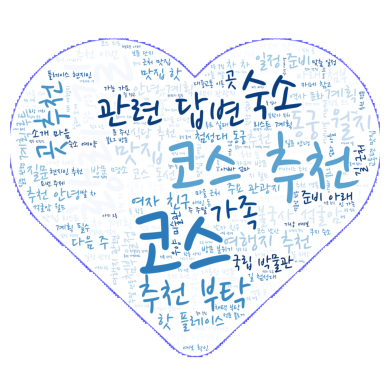

In [95]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt
img = Image.open('data/heart.jpg')
mask = np.array(img)
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf',
    background_color= 'white',
    colormap='Blues',
    collocations= True, # 특정단어가 자주 같이 나오면 같이 뿌리기 ex)황리길
    max_words=200,
    scale=2, # 이미지 크기의 비율 (파일 저장시)
    mask = mask,
    contour_color = 'blue',
    contour_width = 1
).generate(gj_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show

In [96]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/gj_wordcloud.jpg')

<function matplotlib.pyplot.show(close=None, block=None)>

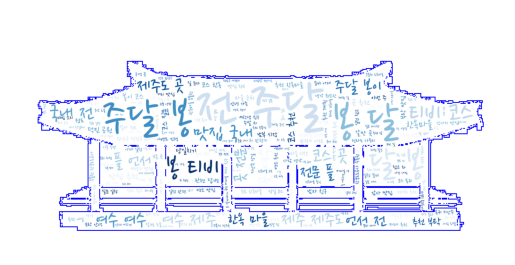

In [97]:
img = Image.open('data/korea-house-black-fill.png')
mask = np.array(img)
wordcloud = WordCloud(
    font_path='data/NanumPenScript-Regular.ttf',
    background_color= 'white',
    colormap='Blues',
    collocations= True, # 특정단어가 자주 같이 나오면 같이 뿌리기 ex)황리길
    max_words=200,
    scale=2, # 이미지 크기의 비율 (파일 저장시)
    mask = mask,
    contour_color = 'blue',
    contour_width = 1
).generate(jj_text)
plt.imshow(wordcloud)
plt.axis('off')
plt.show

In [98]:
# 생성된 wordcloud 저장
wordcloud.to_file('data/jj_wordcloud.jpg')

## 빈도수 시각화(nltk, Text)

In [ ]:
df_gj_noun_list = df_nouns.loc[df_nouns['query']=='경주 여행', 'token'].to_list()
df_jj_noun_list = df_nouns.loc[df_nouns['query']=='전주 여행', 'token'].to_list()

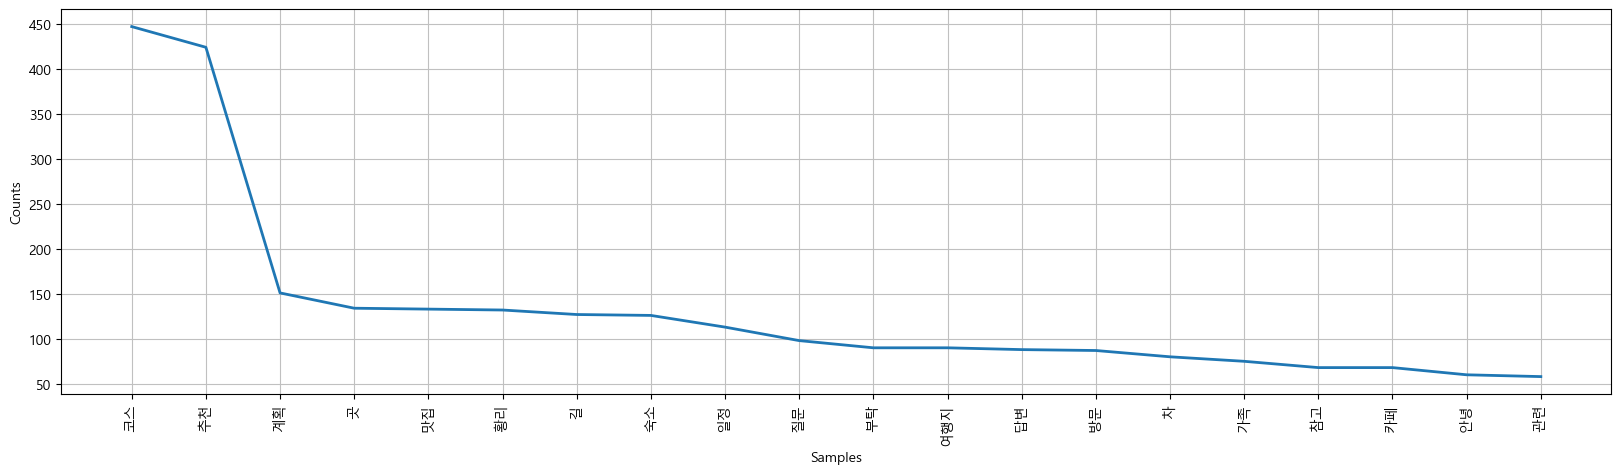

In [99]:
import nltk
data_text = nltk.Text(df_gj_noun_list)
plt.figure(figsize=(20,5))
plt.rc('font', family="malgun Gothic")
data_text.plot(20)
plt.show()

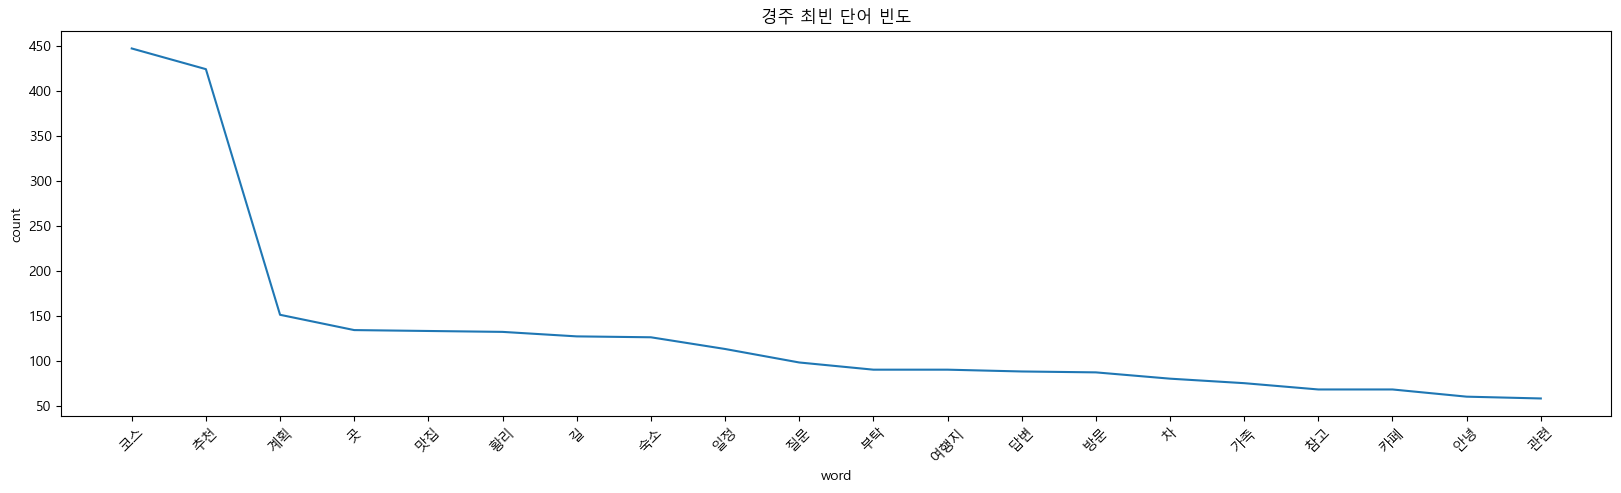

In [105]:
word, counts = zip(*data_text.vocab().most_common(20))
# print(word)
# print(counts)
plt.figure(figsize=(20,5))
plt.plot(word,counts)
plt.xticks(rotation=45)
plt.xlabel('word')
plt.ylabel('count')
plt.title('경주 최빈 단어 빈도')
plt.show()

# 6. 유사도 분석
## Word2Vec

In [108]:
df = pd.read_csv('data/naver.csv', encoding='cp949') 
df.sample()

,query,no,title,link,description,total_text
510,경주 여행,11,경주여행 30만원,https://kin.naver.com/qna/detail.naver?d1id=9&...,경주 여행 2박3일 남자친구랑 가는데 숙소랑 ktx비는 다 냈고 제 개인적으로 30...,경주여행 30만원 경주 여행 2박3일 남자친구랑 가는데 숙소랑 ktx비는 다 냈고 ...


In [110]:
total_text_list = df['total_text'].to_list()
total_text_list[:2]

['25년10월5,6,7일 전주여행  전주여행 가볼만한 곳 추천부탁드립니다 25년 10월 초 전주여행 아이들과 함께 가기 좋은 시점이에요 추석에는 문 연 곳이 적을 수 있지만 전주 한옥마을이나 전주비빔밥 맛집은 추천해용 차는 밀릴 가능성이 높으니 미리 출발하는 ',
 'KTX로 떠나는 전주 여행, 주요 관광지 도보 이동...   전주 여행 계획 중이시군요 전주역에서 한옥마을까지는 사실 도보로는 좀 멀어요 약 3km 정도 되고 40분 정도 걸립니다 그래서 대부분 택시나 버스를 이용하시는데 택시는 10분 정도면 도착하고 요금도 7 8천원 정도로 부담 없어요 ']

In [112]:
from mecab import MeCab
select_pos = ['NNP', 'NNG']
불용어 ={'여행'}
analyzer = MeCab()
total_noun_list = []
for total_text in total_text_list:
    noun_list = [token for token, tag in analyzer.pos(total_text)
                    if tag in select_pos and 
                     token not in 불용어 and
                     len(token)>1]
    total_noun_list.append(noun_list)
print(total_noun_list[:2])

[['전주', '전주', '추천', '부탁', '전주', '아이', '시점', '추석', '전주', '한옥마을', '전주비빔밥', '맛집', '추천', '해용', '가능', '출발'], ['전주', '주요', '관광지', '도보', '이동', '전주', '계획', '주역', '한옥마을', '도보', '정도', '정도', '대부분', '택시', '버스', '이용', '택시', '정도', '도착', '요금', '정도', '부담']]


In [113]:
from gensim.models import Word2Vec
model = Word2Vec(total_noun_list, window=10, min_count=2, workers=-1, 
                sg=1) # 소량 데이터

In [114]:
model.wv.most_similar('전주')

[('부부', 0.3595535457134247),
 ('야경', 0.2897421419620514),
 ('리스트', 0.275379478931427),
 ('덕진구', 0.2731468081474304),
 ('코로나', 0.2580290138721466),
 ('전라도', 0.2295033037662506),
 ('미술관', 0.22023281455039978),
 ('답변', 0.21883943676948547),
 ('한옥마을', 0.21617142856121063),
 ('시절', 0.2135322391986847)]

In [115]:
model.wv.most_similar('경주')

[('편리', 0.3641005754470825),
 ('영화제', 0.21867415308952332),
 ('할증', 0.21632219851016998),
 ('연령', 0.2159893959760666),
 ('완산구', 0.21469099819660187),
 ('황동', 0.2134207934141159),
 ('독일', 0.20914912223815918),
 ('포석정', 0.20906010270118713),
 ('패딩', 0.2070489227771759),
 ('개인', 0.20607852935791016)]

## 연관분석

In [118]:
print(total_noun_list[:2])

[['전주', '전주', '추천', '부탁', '전주', '아이', '시점', '추석', '전주', '한옥마을', '전주비빔밥', '맛집', '추천', '해용', '가능', '출발'], ['전주', '주요', '관광지', '도보', '이동', '전주', '계획', '주역', '한옥마을', '도보', '정도', '정도', '대부분', '택시', '버스', '이용', '택시', '정도', '도착', '요금', '정도', '부담']]


In [125]:
%%time
from apyori import apriori
rules = apriori(total_noun_list, min_suppoort=0.15, min_confidence=0.3, min_lift=1.01)
rules = list(rules)
len(rules)

CPU times: total: 5.19 s
Wall time: 5.19 s


3201

In [126]:
rules_df = pd.DataFrame(None, columns=['lhs','rhs','지지도','신뢰도','향상도'])
rules_df

,lhs,rhs,지지도,신뢰도,향상도


In [ ]:
idx = 0
for row in rules:
    support = row[1]
    ordered_st= row[2]
    #print('지지도 :', support)
    # print('순서들 :', ordered_st)
    for item in ordered_st:
        #print(item)
        lhs = item[0]
        lhs = ','.join([x for x in lhs])
        rhs = item[1]
        rhs =  ','.join([x for x in rhs])
        confidence = item[2]
        lift = item[3]
        rules_df.loc[idx] =[lhs, rhs, support, confidence, lift]
        idx +=1
            #print('{:10}=>{:11}\t{}\t{:.2f}\t{:.2f}'.format(lhs, rhs, support, confidence, lift))
rules_df.sort_values(by=['신뢰도','향상도'],ascending=False)        

In [ ]:
rules_df.head(20)